## Interactive Route Finder

### Introduction
In this part of the project we will create an interactive map where the user can mark two points on `Tehran` and see the shortest route.

## Steps:


### Step1. getting Tehran's map data:
First we should get Therans map data with `pyrosm` . 

### Step2. get network data
Now we should get network data using `osm.get_network` and set the type of network to driving from pyrosm the OSM actualy read the given data and the osm is the actually initialized reader instance for the given PBF dataset that should always be used to make the calls for fetching different datasets from the OpenStreetMap PBF -file. Here we get the network data as `nodes` and `edges` to build the graph in next step.

### Step3. create graaph
Here we create the graph of network data using `osm.to_graph` and set the type of graph to networkx.

In [3]:
from pyrosm import OSM
from pyrosm import get_data
from ipyleaflet import Map, Marker, AntPath
from pyrosm import OSM
import networkx as nx
import osmnx as ox
data = get_data("tehran")
osm = OSM(data)
nodes, edges = osm.get_network(nodes=True, network_type="driving")
graph = osm.to_graph(nodes, edges, graph_type="networkx")

### Step4. create interactive map and clalulate the shortest rout for showing on map
We creat a class for this purpess first using `Map` from `ipyleaflet` and passing the center of Teharan to it we create an interactive map . Then with passing location_mark method(method of class) to on_interaction method(method of map) we call location_mark with every interaction on the map. In location_mark method we set that if interaction was click then the coordinates that clicked on will return and then we choose closest node to coordinates that were clicked using `ox.nearest_nodes` from `osmnx` we select the coordinates associated with the id that ox returnes it and we set a marker with that coordinates using `Marker` from ipyleaflet we repeat this for second marker and if user click for third time both  markers will remove. Now when both locations are selcted we call the `calculate_shortest_distance` method in this method we take a list of id's in shortest path using `nx.shortest_path` (source_node and target_node are locations of markers in id form). Now we extract the coordinates of id's from the graph. Now we create an antpath using `AntPath` from ipyleaflet an add this to the map (i.e with third click on the map after selcting markers the antpath is also removed from the map)

In [4]:

class Shortest_distandse:
    center = (35.7219, 51.3347)
    
    def __init__(self): 
        self.map = Map(center = self.center, zoom = 12)
        self.counter = 0
        self.graph = graph
        self.nodes = nodes
        self.edges = edges

    def location_mark(self, **kwargs):
        if kwargs["type"] == "click":
            if self.counter == 0:
                self.source_location = kwargs["coordinates"]
                self.marker1_location = self.nodes.loc[self.nodes["id"] == ox.nearest_nodes(self.graph, self.source_location[1],self.source_location[0])][["lat","lon"]].values.tolist()[0]
                self.marker1 = Marker(location = tuple(self.marker1_location), draggable = False)
                print(self.marker1_location)
                self.map.add(self.marker1)
                self.counter += 1
            elif  self.counter == 1:
                self.target_location = kwargs["coordinates"]
                self.marker2_location = self.nodes.loc[self.nodes["id"] == ox.nearest_nodes(self.graph, self.target_location[1],self.target_location[0])][["lat","lon"]].values.tolist()[0]
                self.marker2 = Marker(location = self.marker2_location, draggable = False)
                self.map.add(self.marker2)
                self.counter += 1
                self.calculate_shortest_distance()
            else :
                self.counter = 0
                self.map.remove(self.marker2)
                self.map.remove(self.marker1)
                self.map.remove(self.ant_path)

    def calculate_shortest_distance(self):
        self.source_node = ox.nearest_nodes(self.graph, self.source_location[1],self.source_location[0])
        self.target_node = ox.nearest_nodes(self.graph, self.target_location[1],self.target_location[0])
        self.route = nx.shortest_path(self.graph, self.source_node, self.target_node, weight="length")
        self.path = [[self.graph.nodes[node]['y'], self.graph.nodes[node]['x']] for node in self.route]
        self.ant_path = AntPath(locations = self.path, delay=2000, dash_array = [1, 10], color="#48e4ff", pulse_color="#095328")
        self.map.add(self.ant_path)

o1 = Shortest_distandse()
o1.map.on_interaction(o1.location_mark)

o1.map

Map(center=[35.7219, 51.3347], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zo…


## **displaying the shortest path between two interactively chosen points (OOP)**
author: Zahra Gharib

part 1


In [ ]:
from pyrosm import OSM, get_data
import osmnx as ox
from ipyleaflet import Map, Marker, Polyline

class ShortestPath:
    def __init__(self):
        self.current_route = None
        self.markers = []
        osm = OSM(get_data("Tehran"))
        nodes, edges = osm.get_network(nodes=True, network_type="driving")
        self.graph = osm.to_graph(nodes, edges, graph_type="networkx")
        center = (35.6892, 51.3890)
        self.my_map = Map(center=center, zoom=15)

        self.my_map.on_interaction(self.click_handler)


    def click_handler(self, **kwargs):
        if kwargs.get("type") == "click":
            lat, lon = kwargs.get("coordinates")
            
            self.add_marker(lat, lon)

            if len(self.markers) > 2:
                self.clear_markers()
                return
            
            if len(self.markers) == 2:
                self.draw_marker_on_graph()
            

    def clear_markers(self):
        for marker in self.markers:
            self.my_map.remove_layer(marker) 
        self.markers.clear()

        if self.current_route:
            self.my_map.remove_layer(self.current_route)
            self.current_route = None
        return


    def add_marker(self, lat, lon):
        marker = Marker(location= (lat, lon), draggable=False)
        self.markers.append(marker)
        self.my_map.add_layer(marker)


    def draw_marker_on_graph(self):
        self.origin = self.markers[0].location #(lat, lon)
        self.dest = self.markers[1].location   #(lat, lon)

        self.origin_node = ox.distance.nearest_nodes(self.graph, self.origin[1], self.origin[0])
        self.dest_node = ox.distance.nearest_nodes(self.graph, self.dest[1], self.dest[0])

        self.route = ox.shortest_path(self.graph, self.origin_node, self.dest_node, weight="length")


        route_coord = []
        for node_id in self.route:
            node = self.graph.nodes[node_id]
            route_coord.append((node['y'], node['x']))
        
        if self.current_route:
            self.my_map.remove_layer(self.current_route)
        self.current_route = Polyline(locations= route_coord, color="red", weight=7)
        self.my_map.add_layer(self.current_route)

my_shortest_path = ShortestPath()
display(my_shortest_path.my_map)

Map(center=[35.6892, 51.389], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoo…

## **Step 1. modules and libraries**

In [1]:
from pyrosm import OSM, get_data
import osmnx as ox
from ipyleaflet import Map, Marker, Polyline

## **Step 2. initializing**
`current_route`: at first initialized with `None` 

`markers`: for interactively selected points on the map

`nodes` & `edges`: after extracting Tehran map by `get_data`, now we get the map's `nodes` and `edges`

`graph`: using `nodes` & `edges`, now we create a `graph`

`center`: we need the center of Tehran on the map

`my_map`: now using the map sub-module from ipyleaflet module, we create a map, the center of which is `center`

`my_map.on_interactopn(self.click_handler)`: the `self.click_handler` here is a callback function which will be triggered when user interacts with `my_map`

In [2]:
class ShortestPath:
    def __init__(self):
        self.current_route = None
        self.markers = []
        osm = OSM(get_data("Tehran"))
        nodes, edges = osm.get_network(nodes=True, network_type="driving")
        self.graph = osm.to_graph(nodes, edges, graph_type="networkx")
        center = (35.6892, 51.3890)
        self.my_map = Map(center=center, zoom=15)

        self.my_map.on_interaction(self.click_handler)


## **Step 3. click_handler function**

As we said earlier, if the user interacts with `my_map`, this function will be triggered. Now if the interaction event is "click", it will get the coordinates of the clicked point.

There are some coditions. first, if we have more than 2 markers in `self.markers`, it means the user has already chosen their points and their clicks have been handled. So the function will clear the markers and break from the function

If we stay in the function, we'd want to add the markers in `my_map` and also have them in the `self.markers` list

Second, if we have just 2 markers, we'll want to have them so the `draw_marker_on_graph` will be called

In [ ]:
def click_handler(self, **kwargs):
    if kwargs.get("type") == "click":
        lat, lon = kwargs.get("coordinates")
        
        self.add_marker(lat, lon)

        if len(self.markers) > 2:
            self.clear_markers()
            return
        
        if len(self.markers) == 2:
            self.draw_marker_on_graph()

## **Step 4. clear_markers function**

When the number of markers crossed 2, we were to clear `my_map`. So this function, removes the markers exsiting in `self.markers` list from the map and from the list itself.

And also we'd want to remove the route on `my_map` if existed. So if we have a `current_route`, the function removes its layers and initializes the `currrent_route` with `None` again

In [4]:

def clear_markers(self):
    for marker in self.markers:
        self.my_map.remove_layer(marker) 
    self.markers.clear()
    if self.current_route:
        self.my_map.remove_layer(self.current_route)
        self.current_route = None
    return

## **Step 5. add_marker function**

We needed this function when the number of markers was fewer than 2. 

We have the lat & lon (extracted from `click_handler` by kwargs.get('coordinates')), we'll pass them to the function.

It will first create the markers, then add them in `self.markers` list and finally add the layers to `my_map`

In [5]:
def add_marker(self, lat, lon):
    marker = Marker(location= (lat, lon), draggable=False)
    self.markers.append(marker)
    self.my_map.add_layer(marker)


## **Step 6. draw_marker_on_graph**

We used this function when we made sure that we have only 2 markers in `click_handler`.

now, the origin point is the first element in `self.markers` list and the destination point is the secont one

Each element in `self.markers` is a marker obj, so in order to access their lat & lon, we should use `.location`. It gives us (lat,lon)

Now we need the nearest nodes to the origing & destination coordinates. We'll get it using, `ox.distance.nearest_nodes`. It gets (lon,lat)

Then we need `ox.shortest_path` to find the route which is the shoertest one (`weight=lenght` since we're looking for the distance and the length)

`self.route` here is a list of node IDs. We'll convert them into geographic coordinates (lat, lon pairs).

`self.graph.nodes[node_id]` returns a dictionary like: 

{
    'y' :  35.6892,           # Latitude
    'x ':  51.3890,       # Longitude
    'street_count' :  3   # Number of connected roads (optional)
    } 

then we add lat and lon to the list `route_coord` as a tuple

now if we have a `self.current_route` we remove it from the map to apply the route we want on the map again



In [6]:

def draw_marker_on_graph(self):
    self.origin = self.markers[0].location #(lat, lon)
    self.dest = self.markers[1].location   #(lat, lon)

    self.origin_node = ox.distance.nearest_nodes(self.graph, self.origin[1], self.origin[0])
    self.dest_node = ox.distance.nearest_nodes(self.graph, self.dest[1], self.dest[0])

    self.route = ox.shortest_path(self.graph, self.origin_node, self.dest_node, weight="length")


    route_coord = []
    for node_id in self.route:
        node = self.graph.nodes[node_id]
        route_coord.append((node['y'], node['x']))
    
    if self.current_route:
        self.my_map.remove_layer(self.current_route)
    self.current_route = Polyline(locations= route_coord, color="red", weight=7)
    self.my_map.add_layer(self.current_route)


## **Step 7. make a class instance**

In [ ]:
my_shortest_path = ShortestPath()
display(my_shortest_path.my_map)

## **University Influence Erea Analysis**



## Introduction
in the second part of the project, we want to work on "influence era" and the accessibility zone of each univerisy in Tehran


## Steps

## Step 1. Modules and Libraries

`OSM`: Extracting Tehran's map data .

`Geopandas`: Handling geographical data .

`Pandas`: Handling tabular data .

`BallTree` from `sklearn`: Finding nearest points efficiently .

`Numpy`: Numercial calculation .

`Matplotlib`: data visualization .

`Networkx`: Working with road network graphs .

`LinearSegmentedColormap`:  Creating custom color gradients .



In [6]:
from pyrosm import OSM, get_data
import geopandas as gpd
import pandas as pd
from sklearn.neighbors import BallTree
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.colors import LinearSegmentedColormap

## Step 2. Helper functions

**get_nearest funcction:**


It finds the nearest neighbors betwen two sets of geographic coordinates(source points) unsing BallTree
BallTree is an efficient algorithm for finding closest points. it uses the `Haversine` distance which is best suited for geographic coordinates
This function finds the nearest neighbor in candidates for each point in scr_points and returns the distance

`src_points`: array-like structure containing the coordinates of the source points for which we want to calculate the nearest neighbors .

`candidates`: array-like structure containing the candidate points from which we will selecet the nearest neighbors .

`haverinse`: Haversine distance will be used, which is suitable for calculating distances on the surface of a sphere (like Earth) .

`k_neighbor=1`: returning one single nearest neighbor .

`leaf_size`: The number of points in each leaf node of the tree

`tree.query`: This line queries the BallTree for the nearest neighbors of the source points, returning two 2D arrays(distance between src point and nearest neighbor, index)

`[:,0]`: the : indicates that we want to selecet all rows of the array and the 0 indicates that we want the first element in each row

In [7]:
def get_nearest(src_points, candidates, k_neighbors=1):
    """Find nearest neighbors using BallTree"""
    tree = BallTree(candidates, leaf_size=15, metric='haversine')
    distances, indices = tree.query(src_points, k=k_neighbors)
    return indices[:,0], distances[:,0]

** For Example**

In [8]:
import numpy as np
from sklearn.neighbors import BallTree

def get_nearest(src_points, candidates, k_neighbors=1):
    """Find nearest neighbors using BallTree"""
    tree = BallTree(candidates, leaf_size=15, metric='haversine')
    distances, indices = tree.query(src_points, k=k_neighbors)
    return indices[:,0], distances[:,0]

# Coordinates in degrees (latitude, longitude)
src_points_deg = np.array([
    [34.0522, -118.2437],  # Los Angeles
    [40.7128, -74.0060],   # New York
    [51.5074, -0.1278]     # London
])

candidates_deg = np.array([
    [34.0522, -118.2437],  # Los Angeles
    [36.1699, -115.1398],  # Las Vegas
    [37.7749, -122.4194],  # San Francisco
    [40.7306, -73.9352],   # New York City
    [51.5074, -0.1278]     # London
])

# Convert degrees to radians for haversine metric
src_points_rad = np.radians(src_points_deg)
candidates_rad = np.radians(candidates_deg)

indices, distances = get_nearest(src_points_rad, candidates_rad, k_neighbors=1)

print(indices)
print(distances)
# print(distances * 6371)  # Earth's radius approx 6371 km



[0 3 4]
[0.        0.0009867 0.       ]


**nearest_neighbor function**

It finds the closest points between 2 GeoDataFrame(left, right) .
It converts coordinates to radians(for geographic calculations) .
It finds the neatest neighbor using BallTree .

`left_radians`: converts the left_gpf(src points) from degree to radians. since geographic calculation such as haversine requiers radians

`left_gdf.geometry`: extracts the geometry column from the GeoDataFrame

`lambda function`: geom.x extracts langitude and geo.y extracts latitude and the degree times pi devided by 180 will give the radian

Then it will be a list of tuples e.g. [(lon, lat), (lon, lat), ...] .
and then it will be converted to a numpy array .


The left_radian as the source points and the right_radian as the candidate points will be given to the nearest_neighbor function to calculate .
And the index of the nearest point will be in closest and the distance(in radians) will be in dist variable .



As the indices-array is in closest and the iloc will get an index and give the row resembling the index, 

`reset_index()` resets the index of the selected rows so that they are numbered sequentially .

`drop=True` ensures that the old index is removed rather than added as a new column.



Then the distance will be converted from radian into meter

And the GeoDataFrame with the nearest points, including distance will be returned


In [9]:
def nearest_neighbor(left_gdf, right_gdf, return_dist=False):
    """Find closest points between two GeoDataFrames"""
    left_radians = np.array(
        left_gdf.geometry.apply(
            lambda geom: (geom.x * np.pi/180, geom.y * np.pi/180)
        ).tolist()
    )
    
    right_radians = np.array(
        right_gdf.geometry.apply(
            lambda geom: (geom.x * np.pi/180, geom.y * np.pi/180)
        ).tolist()
    )
    
    closest, dist = get_nearest(left_radians, right_radians)
    closest_points = right_gdf.iloc[closest].reset_index(drop=True)
    
    if return_dist:
        closest_points['distance'] = dist * 6371000  # Earth radius in meters
    
    return closest_points

## **Step 3. Loading Tehran Data**

`OSM(get_data())`: downloads Tehran map data from OSM

`osm.get_network`: loads the road network and extracts nodes and edge(drinving network type)

`osm.get_pois`: extracts the universities as points of interest

`osm.get_building`: loads building data

In [10]:
print("Loading Tehran data...")
osm = OSM(get_data("Tehran"))
nodes, edges = osm.get_network(nodes=True, network_type="driving")
universities = osm.get_pois(custom_filter={"amenity": ['university']})
buildings = osm.get_buildings()

Loading Tehran data...


## **Step 4. Proccessing Data and the Graph**

`osm.to_graph`: using networkx, converts the nodes and edges into a graph

`nodes.rename`: for better readability and debuging further error, renames the id to node_id

In [11]:
print("Preparing data...")
graph = osm.to_graph(nodes, edges, graph_type="networkx")
nodes = nodes.rename(columns={'id': 'node_id'})

Preparing data...


## **Step 5. Convert Geometries to Centroids & Convert to EPSG:4326 Coordinate System**

`.centroid`: Extracts the central point of each geometry.

`universities.geometry.centroid`: computes the centroid of each university's polygon. The same applies for the buildings .

`to_crs`: For correct distance calculation .

`EPSG:4326`: Is WGS84, the standard latitude/longitude system used in GPS .


In [12]:
universities["geometry"] = universities.geometry.centroid
buildings["geometry"] = buildings.geometry.centroid

# Set consistent CRS
universities = universities.to_crs("EPSG:4326")
buildings = buildings.to_crs("EPSG:4326")
nodes = nodes.to_crs("EPSG:4326")

C:\Users\User\AppData\Local\Temp\ipykernel_8408\1798424075.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  universities["geometry"] = universities.geometry.centroid
C:\Users\User\AppData\Local\Temp\ipykernel_8408\1798424075.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buildings["geometry"] = buildings.geometry.centroid


## **Step 6. Finding the nearest node for each university**
(In order to connect the universities to the road network we need Euclidean distance.)

Finds the nearest road network node to each university using the helper nearest_neighbor function

Stores the node ID and Euclidean distance

Here nodes & universities are GeoDataFrames

`return_dis = True`: ensures the distance to the nearest node is returned by the function and not just the matched node

`universities["node_id"] = closest_nodes["node_id"]`: 
Extractss the `node_id` column from `closest_nodes`, which contains the ID of the nearest nodes from the road network, then adds this ID to the `universities` GeoDataFrame so each university is linked to its closest road node




`universities["node_distance"] = closest_nodes["distance"]`:
Stores the distance in meter between each uni and its nearest road neatwork node


In [13]:
closest_nodes = nearest_neighbor(universities, nodes, return_dist=True)
universities["node_id"] = closest_nodes["node_id"]
universities["node_distance"] = closest_nodes["distance"]

## **Step 7. Calculating shortest path between unis and building**

Using the Dijkstra's algorithm to find the shortest path from each uni and all the other nodes.

Stores the distance in a dict

As the `universities` is a GeoDataFrame, idx is the index of the uni in the dataFrame and uni will be the data of the university, including its nearest road network node(`node_id`)

The `end=\'r'` will overwrite the existing line that was printed

The `Try` block: finds the shortest path from the university's neatest road node(`node_id`) to all other nodes in the road network graph(`graph`), using the dijkstra's algorithm

`Path`: Path is a dict. It stores the shortest distance from a single univeristy's nearest node to every other node in the graph
The keys: node IDs
The values: shortest path length

`distances = np.array([paths.get(n, float('inf')) for n in nodes['node_id']])`:
we loop through the `node_id` as n and give it to `path(a dict).get`. If path.get(n) doesn't return a valid distance, it will assign float('inf) as if no connection exists
And it will be convertecd into a np array and stored in distance variable



`distances += uni["node_distance"`: Ensures that calculation starts from the university itself, and not the closest road node.

`distance_cols[f"dist_to_uni_{idx}"] = distances`: Saves the computed distance to the dict using `idx` so it would be unique

`pd.concat([nodes, pd.DataFrame(distance_cols)], axis=1)`: First we convert the dic (`distance_cols`) into a GeoDataFRame, then merges it with the `nodes` GeoDateFrame. and finally each node has a column for the shortest distance to each university

In the last line, we find the min distance(shortest distance amoung all) from each node to any university
Now each node is assigned with the closest uni 

In [14]:
distance_cols = {}
for idx, uni in universities.iterrows():
    print(f"Processing university {idx+1} of {len(universities)}...", end='\r')
    try:
        paths = nx.single_source_dijkstra_path_length(graph, source=uni["node_id"], weight='length')
        distances = np.array([paths.get(n, float('inf')) for n in nodes['node_id']])
        distances += uni["node_distance"]  # Add euclidean distance
        distance_cols[f"dist_to_uni_{idx}"] = distances
    except Exception as e:
        print(f"Error processing university {idx}: {e}")

# Add distances to nodes
nodes = pd.concat([nodes, pd.DataFrame(distance_cols)], axis=1)

# Find minimum distance to any university
nodes["min_distance"] = nodes[[c for c in nodes.columns if c.startswith("dist_to_uni_")]].min(axis=1)


Error processing university 67: Node 12325414556 not found in graph
Error processing university 89: Node 12325414556 not found in graph
Error processing university 98: Node 3886106317 not found in graph
Error processing university 146: Node 4509978776 not found in graph


## **Step 8. Connecting buildings to the road network**

Using the helper nearest_neighbor function, it finds the nearest node on the road network for each building

Stores the node ID and distance

Merges the `buildings` GeoDataFrame with the `nodes` GeoDataFrame. Keeps only `node_id` (the nearest road network node) and `mid_distance` (the shortest path distance to the nearest uni)

`how=left`: Keeps all the buildings even if they have a missing value in `node_id` in `nodes`


`access["node_distance"] + access["min_distance"]`: Computes the total distance a building has to the nearest uni. 
`node_distance`: the Euclidean distance from the building to its closest road node
`min_distance`: the network travel distance from the `node_distance` to the nearest uni

Then stores the distance in km instead of m


Then blocks all the building that their distance is too long

In [15]:
print("\nConnecting buildings...")
closest = nearest_neighbor(buildings, nodes, return_dist=True)
buildings["node_id"] = closest["node_id"]
buildings["node_distance"] = closest["distance"]

# Merge with distance data
access = buildings.merge(
    nodes[["node_id", "min_distance"]],
    on="node_id",
    how="left"
)
access["total_distance"] = access["node_distance"] + access["min_distance"]
access["distance_km"] = (access["total_distance"] / 1000)

# Filter buildings too far from network
access = access[access["node_distance"] <= 5000]


Connecting buildings...


## **Step 9. Creating a HeatMap for visualization**

Creating a fig and an axis obj usiing `matplotlib`

Creates a custom color gradient (red to yellow to white) for the heatmap.

`alopha=0.8`: makes points slightly trasparent and vivid for better visibility

`plt.tight_layout`:  optimizes spacing so elements don't overlap



Creating heatmap...


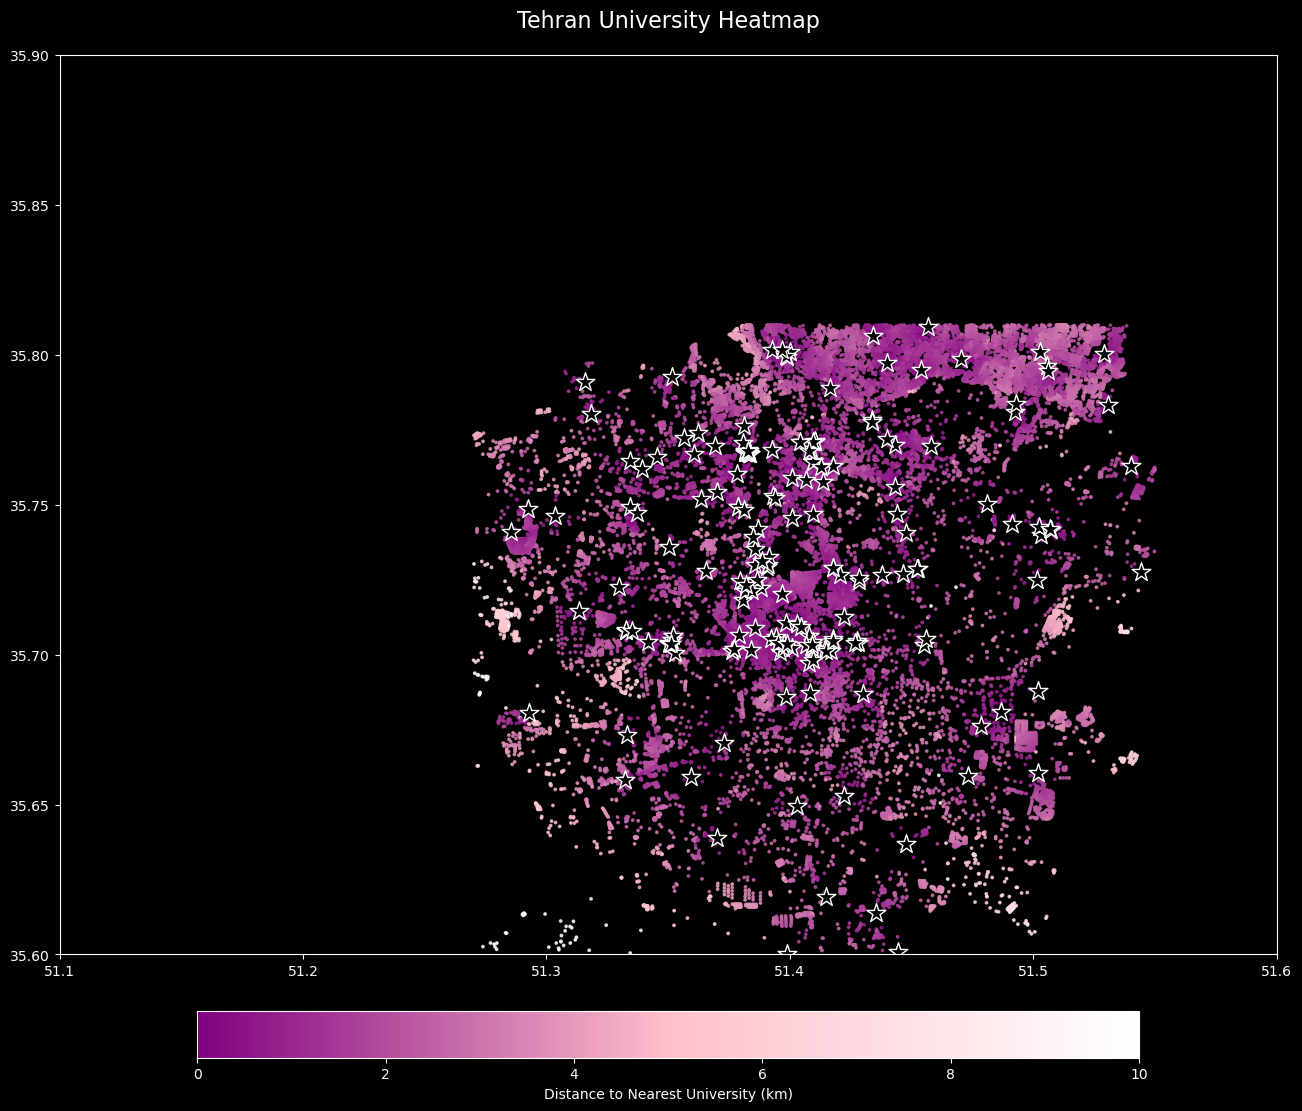

In [17]:
print("Creating heatmap...")
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(16, 12))

# Create red-to-white colormap
cmap = LinearSegmentedColormap.from_list('heatmap', ['purple', 'pink', 'white'])

# Normalize distances for coloring (0-10km range)
max_dist = 10  # km
access["color_value"] = np.clip(access["distance_km"], 0, max_dist) / max_dist

# Plot buildings with heatmap colors
access.plot(
    ax=ax,
    column="distance_km",
    markersize=3,
    alpha=0.8,
    cmap=cmap,
    vmin=0,
    vmax=max_dist,
    legend=True,
    legend_kwds={
        'label': "Distance to Nearest University (km)",
        'orientation': 'horizontal',
        'shrink': 0.6,
        'pad': 0.05
    }
)

# Plot universities
universities.plot(
    ax=ax,
    color='black',
    markersize=200,
    marker='*',
    edgecolor='white',
    label='Universities'
)

# Set Tehran boundaries
ax.set_xlim(51.1, 51.6)
ax.set_ylim(35.6, 35.9)
ax.set_title("Tehran University Heatmap", fontsize=16, pad=20)

plt.tight_layout()
plt.show()